# Setup & Configuration

In [ ]:
#downloading CLIP and torchvision
!pip install torch torchvision ftfy regex tqdm Pillow
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-rbu_l8m6
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-rbu_l8m6
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=cb0d9c81f5094b88329ad595a605c34396b19055bfe1af9faf946b8a7c3c2130
  Stored in directory: /tmp/pip-ephem-wheel-cache-t6f5g8v8/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
#mounting google drive
from google.colab import drive
import torch

drive.mount('/content/drive')

#importing faRL model
faRL = "/content/drive/MyDrive/ColourAnalysis/FaRL-Base-Patch16-LAIONFace20M-ep64.pth"
faRL64 = torch.load(faRL)

Mounted at /content/drive


In [ ]:
#to check contents of train dir: !ls "/content/drive/My Drive/ColourAnalysis/rgb_bg_masked/train"

# Data Loading

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Define the base path to the data
base_dir = '/content/drive/My Drive/ColourAnalysis/dataset/rgb_bg_masked'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.4, contrast=0.2, saturation=0.2),
        transforms.RandomAdjustSharpness(sharpness_factor = 2, p = 0.2),
        transforms.ToTensor(),
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]),
}

try:
    # Create datasets using ImageFolder
    # This automatically uses subdirectories as class labels
    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
    test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

    # Create DataLoaders
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Verify the classes and data size
    class_names = train_dataset.classes
    print(f"Classes found: {class_names}")
    print(f"Training data size: {len(train_dataset)} images")
    print(f"Test data size: {len(test_dataset)} images")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print(f"Please check if the directory exists: {base_dir}")

Classes found: ['autunno', 'estate', 'inverno', 'primavera']
Training data size: 4008 images
Test data size: 912 images


## Initialize FaRL64 Model


In [ ]:
import torch
import torch.nn as nn
import clip # Required for clip.load

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the base CLIP model
clip_model_raw, preprocess = clip.load("ViT-B/16", device="cpu")
clip_model_raw = clip_model_raw.to(device)

# Load the FaRL pre-trained weights into the CLIP model
# (faRL variable is defined in a previous cell)
farl_state = torch.load(faRL)
clip_model_raw.load_state_dict(farl_state["state_dict"], strict=False)
# --------------------------------------------------------------------

# Define a new classification model using the FaRL (CLIP) visual encoder as backbone
class FaRLImageClassifier(nn.Module):
    def __init__(self, clip_base_model, num_classes=4):
        super(FaRLImageClassifier, self).__init__()
        self.clip_base_model = clip_base_model

        # Freeze the entire CLIP base model's parameters initially
        for param in self.clip_base_model.parameters():
            param.requires_grad = False

        # The `encode_image` method of the CLIP model outputs features of `embed_dim` (512 for ViT-B/16)
        classifier_in_features = clip_base_model.text_projection.shape[1] # Typically 512

        # Define the new classification head
        self.classification_head = nn.Linear(classifier_in_features, num_classes)

    def forward(self, x):
        # Encode the image using the CLIP model's image encoder
        # This handles the visual transformer and the projection layer internally.
        image_features = self.clip_base_model.encode_image(x.type(self.clip_base_model.dtype))

        # Pass through the classification head
        logits = self.classification_head(image_features)
        return logits

# Instantiate the new classifier model
# class_names is available from a previous cell and has 4 classes.
model = FaRLImageClassifier(clip_model_raw, num_classes=len(class_names)).to(device)

# Unfreeze only the newly added classification head for training
for param in model.classification_head.parameters():
    param.requires_grad = True

# Verify model architecture
print(model)


Using device: cuda


100%|████████████████████████████████████████| 335M/335M [00:02<00:00, 154MiB/s]


FaRLImageClassifier(
  (clip_base_model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDyn

## Configure Optimizer and Scheduler


In [ ]:
import torch.optim as optim

# Configure Optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Configure Scheduler
# T_0: Number of iterations for the first restart
# T_mult: A factor increases T_i after a restart
# eta_min: Minimum learning rate
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-5)

# Define Loss Function
criterion = nn.CrossEntropyLoss()

# Verify initialization
print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")
print(f"Loss Function: {criterion}")

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingWarmRestarts object at 0x78ea29788860>
Loss Function: CrossEntropyLoss()


# Model-Training

In [ ]:
import time
import copy
from tqdm.notebook import tqdm

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dictionaries to store metrics
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = test_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase", leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=25)

Epoch 0/24
----------


train Phase:   0%|          | 0/63 [00:00<?, ?it/s]

train Loss: 1.3260 Acc: 0.4042


test Phase:   0%|          | 0/15 [00:00<?, ?it/s]

test Loss: 1.2821 Acc: 0.4320

Epoch 1/24
----------


...

test Loss: 1.0686 Acc: 0.5088

Epoch 24/24
----------


train Phase:   0%|          | 0/63 [00:00<?, ?it/s]

train Loss: 0.9737 Acc: 0.5873


test Phase:   0%|          | 0/15 [00:00<?, ?it/s]

test Loss: 1.0673 Acc: 0.5066

Training complete in 130m 37s
Best val Acc: 0.5154


In [ ]:
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=1)

Epoch 0/0
----------


train Phase:   0%|          | 0/63 [00:00<?, ?it/s]

train Loss: 0.9840 Acc: 0.5766


test Phase:   0%|          | 0/15 [00:00<?, ?it/s]

test Loss: 1.0682 Acc: 0.5066

Training complete in 2m 34s
Best val Acc: 0.5066


In [ ]:
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=1)

Epoch 0/0
----------


train Phase:   0%|          | 0/63 [00:00<?, ?it/s]

train Loss: 0.9843 Acc: 0.5768


test Phase:   0%|          | 0/15 [00:00<?, ?it/s]

test Loss: 1.0672 Acc: 0.5066

Training complete in 2m 30s
Best val Acc: 0.5066


In [ ]:
#Store results in json
import json
with open('/content/drive/MyDrive/ColourAnalysis/Evaluation/augment_history.json', 'w') as f:
    json.dump(history, f)

# Results

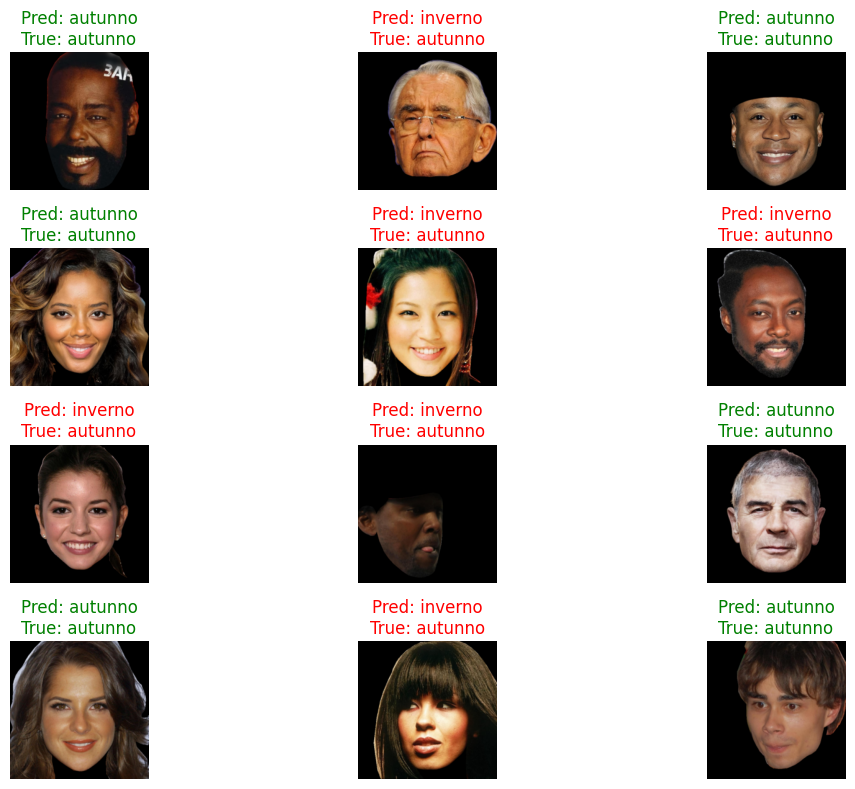

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move to device for prediction
images_cuda = images.to(device)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(images_cuda)
    _, preds = torch.max(outputs, 1)

# Plot the first 6 images
num_images = 12
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(num_images):
    ax = axes[i]
    # Convert Tensor to numpy array and transpose to (H, W, C)
    img = images[i].numpy().transpose((1, 2, 0))
    # Ensure values are valid for plotting (0-1)
    img = np.clip(img, 0, 1)

    ax.imshow(img)

    pred_label = class_names[preds[i]]
    true_label = class_names[labels[i]]

    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

ITA Calculation



In [ ]:
from skimage.color import rgb2lab
import numpy as np

def get_ita_from_tensor(img_tensor):
    # img_tensor is shape (3, H, W), values 0-1
    img_np = img_tensor.numpy().transpose(1, 2, 0)  # → (H, W, 3)

    # mask out black background (already masked images)
    fg_mask = img_np.sum(axis=2) > 0.05
    if fg_mask.sum() < 50:
        return None, "Unknown"

    pixels = img_np[fg_mask]  # (N, 3)
    lab = rgb2lab(pixels.reshape(1, -1, 3)).reshape(-1, 3)
    L_mean = lab[:, 0].mean()
    b_mean = lab[:, 2].mean()

    ita = np.degrees(np.arctan2(L_mean - 50, b_mean))
    return round(ita, 2)

def ita_to_group(angle):
    if angle is None:        return "Unknown"
    if angle > 28:           return "Light"
    elif angle > 10:         return "Tan"
    else:                    return "Dark"

Results with ITA

In [ ]:
results = []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            ita_angle = get_ita_from_tensor(images[i])
            skin_tone = ita_to_group(ita_angle)
            results.append({
                "true_label": class_names[labels[i]],
                "pred_label": class_names[preds[i].item()],
                "skin_tone":  skin_tone,
                "correct":    class_names[labels[i]] == class_names[preds[i].item()],
            })

# Evalution

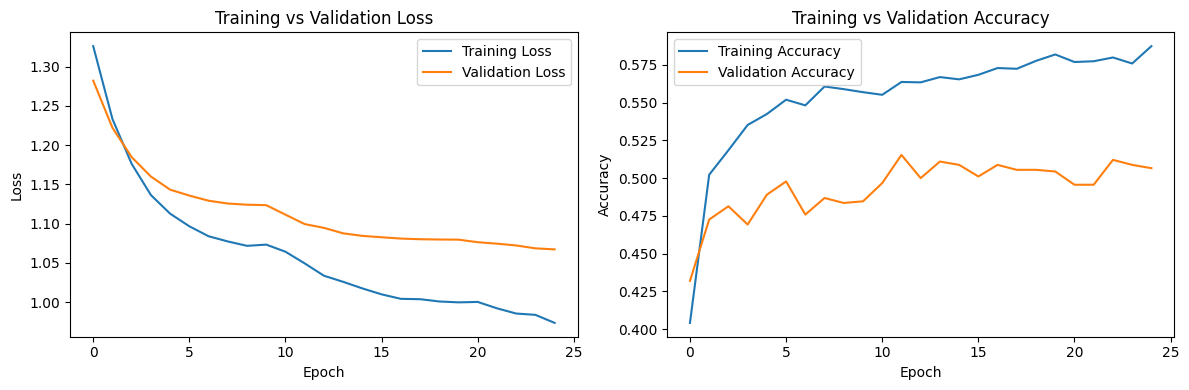

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['test_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['test_acc'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

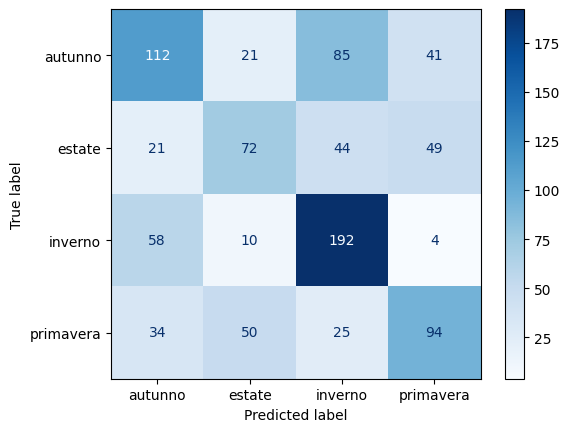

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

model.eval()
class_true = []
class_pred = []

with torch.no_grad():
  for images,labels in test_loader:
    images = images.to(device)
    output = model(images)
    _,predicted = torch.max(output,1)

    class_pred.extend(predicted.cpu().numpy())
    class_true.extend(labels.cpu().numpy())

cm = confusion_matrix(class_true,class_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues')
plt.show()

# Task
Display a 4x4 grid of images from the test set, where each cell (row, column) in the grid represents a true class (row) and a predicted class (column) from the model's performance, showing one example image for each (true_class, predicted_class) combination with its true and predicted labels.

## Prepare Data for Visualization

### Subtask:
Iterate through the test dataset and use the trained model to get predictions. Store images along with their true labels and predicted labels, categorizing them by (true_class, predicted_class) pairs. Select one example image for each unique combination.


**Reasoning**:
I need to implement the logic for preparing data for visualization by iterating through the test dataset, making predictions with the trained model, and storing one example image for each unique combination of true and predicted class labels. This involves setting the model to evaluation mode, processing batches, and populating a dictionary with example images.



In [ ]:
import torch

# 1. Initialize an empty dictionary to store one example image for each unique combination
confusion_examples = {}

# 2. Set the model to evaluation mode
model.eval()

# 3. Iterate through the test_loader to get batches of images and their corresponding true labels
with torch.no_grad(): # Ensure no gradient calculations
    for images, labels in test_loader:
        # 4. For each batch, move the images to the appropriate device
        images = images.to(device)
        labels = labels.to(device)

        # 5. Perform a forward pass with the model to get predictions
        outputs = model(images)

        # 6. Convert the model outputs to predicted class indices
        _, predicted = torch.max(outputs, 1)

        # 7. Iterate through the images, true labels, and predicted labels within the current batch
        for i in range(len(images)):
            true_label_idx = labels[i].item()
            predicted_label_idx = predicted[i].item()

            # Convert indices to class names for the dictionary key if desired, or keep indices
            # Using indices for simplicity as specified: (true_class_idx, predicted_class_idx)
            combination = (true_label_idx, predicted_label_idx)

            # 7b. If this tuple is not yet a key in the confusion_examples dictionary, add it
            if combination not in confusion_examples:
                # Store the current image (CPU tensor) as its value
                confusion_examples[combination] = images[i].cpu().clone() # .clone() to ensure independent copy

print(f"Found {len(confusion_examples)} unique (true_class, predicted_class) combinations.")

# Example of how to access an example:
# for (true_idx, pred_idx), img_tensor in confusion_examples.items():
#     print(f"Combination: True={class_names[true_idx]}, Predicted={class_names[pred_idx]}")
#     # You can now process img_tensor for visualization

Found 16 unique (true_class, predicted_class) combinations.


## Generate Confusion Matrix Examples Plot

### Subtask:
Create a grid of subplots (4x4, for 4 classes) where each subplot displays an example image. The title of each subplot will indicate the true label and the predicted label for that image, representing a cell in the confusion matrix.


**Reasoning**:
The previous step prepared the `confusion_examples` dictionary with example images for each (true_class, predicted_class) combination. Now, I will use this dictionary to create the requested 4x4 grid plot, visualizing the confusion matrix examples as specified in the instructions. This involves iterating through the possible class combinations, retrieving the image, and displaying it with appropriate labels and colors.



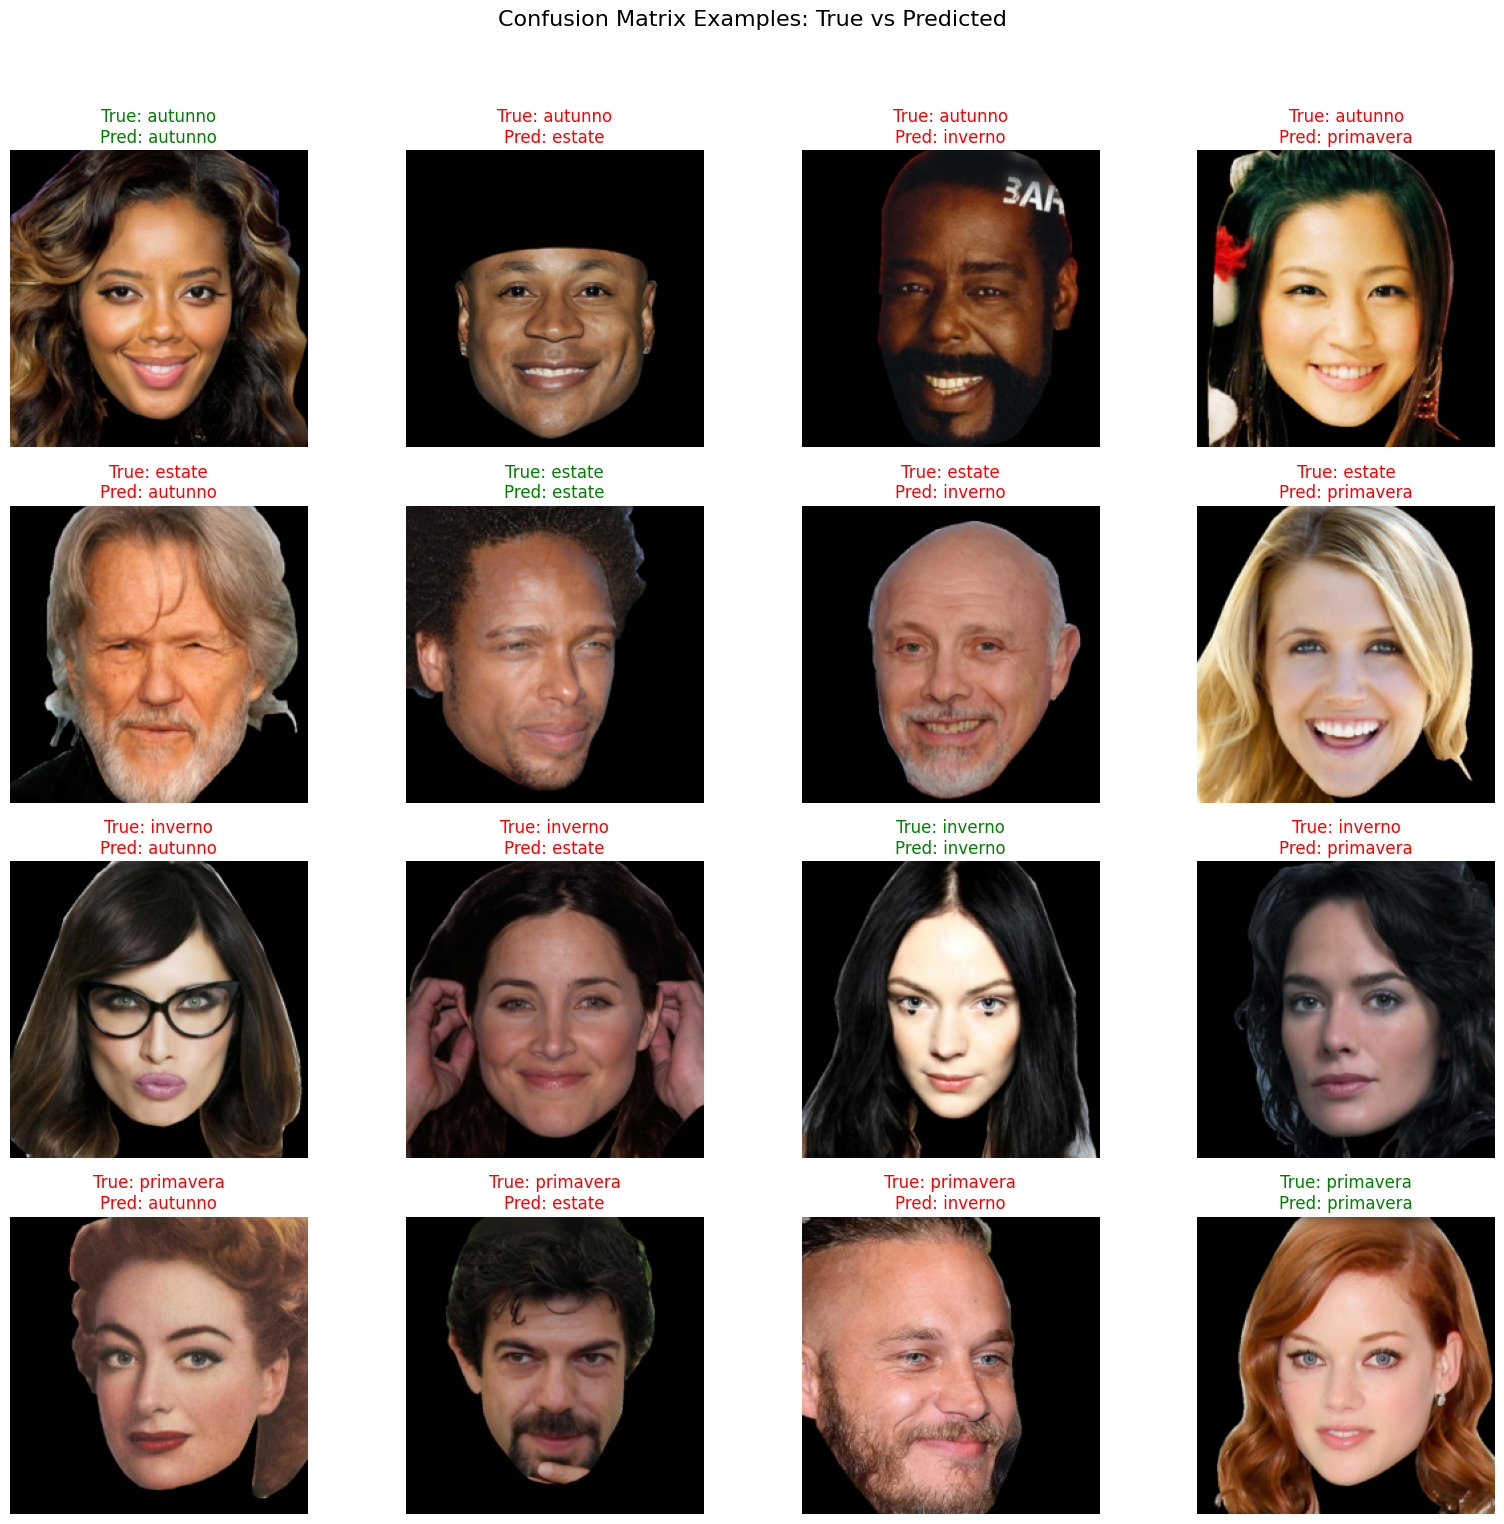

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Determine the number of classes
num_classes = len(class_names)

# Create a figure and a grid of subplots
fig, axes = plt.subplots(num_classes, num_classes, figsize=(16, 16))
fig.suptitle('Confusion Matrix Examples: True vs Predicted', fontsize=16)

# Iterate through each cell in the 4x4 grid
for true_class_idx in range(num_classes):
    for predicted_class_idx in range(num_classes):
        ax = axes[true_class_idx, predicted_class_idx]
        combination = (true_class_idx, predicted_class_idx)

        # Check if an example image exists for the current combination
        if combination in confusion_examples:
            img_tensor = confusion_examples[combination]

            # Convert image tensor from PyTorch (C, H, W) to NumPy (H, W, C)
            # And denormalize/clip values for plotting
            img = img_tensor.numpy().transpose((1, 2, 0))
            img = np.clip(img, 0, 1) # Assuming images are already normalized to [0,1] or similar

            # Display the image
            ax.imshow(img)

            # Set title with true and predicted labels
            true_label_name = class_names[true_class_idx]
            predicted_label_name = class_names[predicted_class_idx]

            title_color = 'green' if true_class_idx == predicted_class_idx else 'red'
            ax.set_title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=title_color)
        else:
            # If no example exists, leave empty or add placeholder
            ax.text(0.5, 0.5, 'No example', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')

        # Turn off axis for each subplot
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

## Final Task

### Subtask:
Display the generated confusion matrix examples plot, showing how the model performed across different true and predicted class combinations.


## Summary:

### Q&A
The task was to display a 4x4 grid of images from the test set. Each cell in the grid represents a unique (true class, predicted class) combination, showcasing one example image with its true and predicted labels. This task was successfully accomplished by generating and displaying the requested plot.

### Data Analysis Key Findings
*   A `confusion_examples` dictionary was successfully populated, storing one representative image for each unique `(true_class, predicted_class)` combination observed in the test dataset. This was achieved by iterating through the test set, using the trained model to generate predictions, and saving the first instance of each combination.
*   A 4x4 grid visualization was generated using `matplotlib`, where each cell corresponds to a specific `(true_class, predicted_class)` combination.
*   Each subplot within the grid displayed an example image (if available for that combination), along with a title indicating its true and predicted labels.
*   Correct classifications (where true class equals predicted class) were highlighted with green titles, while incorrect classifications were indicated with red titles, providing an immediate visual cue for model performance.
*   Subplots for combinations where no example image was found were clearly marked with "No example," indicating certain misclassification or correct classification scenarios might not have occurred in the sampled test set.

### Insights or Next Steps
*   The generated plot offers a valuable qualitative overview of the model's performance, immediately highlighting which classes are being correctly identified and which are frequently confused.
*   Further investigation could focus on the specific examples displayed in the off-diagonal cells (misclassifications) to understand common failure modes, potentially leading to targeted data augmentation or model improvements for those challenging cases.


In [ ]:
import pandas as pd
# 1. overall correct/incorrect % per skin tone
overall = df.groupby("skin_tone")["correct"].agg(
    total="count",
    correct_pct=lambda x: round(x.mean() * 100, 1),
    incorrect_pct=lambda x: round((1 - x.mean()) * 100, 1)
)
print(overall)

# 2. for wrong predictions only — where did they go?
wrong = df[df["correct"] == False]
misclassified = wrong.groupby(["skin_tone", "pred_label"]).agg(
    count=("correct", "count")
).reset_index()

pivot_wrong = misclassified.pivot(
    index="skin_tone", columns="pred_label", values="count"
).fillna(0)

# as percentage of total wrong per skin tone
pivot_wrong_pct = pivot_wrong.div(pivot_wrong.sum(axis=1), axis=0) * 100
print(pivot_wrong_pct.round(1))

              total  correct_pct  incorrect_pct
skin_tone                                      
Brown           247         34.0           66.0
Dark            159         23.3           76.7
Intermediate    106         23.6           76.4
Light            74         24.3           75.7
Tan             303         29.7           70.3
Very Light       23         13.0           87.0
pred_label    autunno  estate  inverno  primavera
skin_tone                                        
Brown            61.3    25.8      4.9        8.0
Dark             67.2    25.4      1.6        5.7
Intermediate     54.3    24.7     11.1        9.9
Light            42.9    26.8     17.9       12.5
Tan              56.3    27.2     13.6        2.8
Very Light       65.0    15.0     10.0       10.0
